# Student Performance Prediction and Model Evaluation




In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
)

pd.set_option('display.max_columns', None)




# Load The Dataset


In [6]:
df = pd.read_csv("student_habits_performance.csv")
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 1. Understanding the Dataset

First, we check the number of rows and columns, column names, data types, and a few records.

In [7]:

print("Rows and columns:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nFirst 5 rows:")
display(df.head())

Rows and columns: (1000, 16)

Column names:
['student_id', 'age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation', 'exam_score']

Data types:
student_id                        object
age                                int64
gender                            object
study_hours_per_day              float64
social_media_hours               float64
netflix_hours                    float64
part_time_job                     object
attendance_percentage            float64
sleep_hours                      float64
diet_quality                      object
exercise_frequency                 int64
parental_education_level          object
internet_quality                  object
mental_health_rating               int64
extracurricular_participation     object
exam_score          

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## 2. Numerical and Categorical Variables

- **Numerical variables** contain numbers and can be used for calculations.
- **Categorical variables** contain groups or labels such as gender or diet quality.

`student_id` is an identifier, so it will not be used as a model feature.

In [8]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(include='object').columns.tolist()

print("Numerical variables:")
print(numerical_cols)

print("\nCategorical variables:")
print(categorical_cols)

Numerical variables:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']

Categorical variables:
['student_id', 'gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


## 3. Basic Statistical Summary

In [9]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
age,1000.0,20.4980,2.308100,17.0,18.750,20.0,23.000,24.0
study_hours_per_day,1000.0,3.5501,1.468890,0.0,2.600,3.5,4.500,8.3
social_media_hours,1000.0,2.5055,1.172422,0.0,1.700,2.5,3.300,7.2
netflix_hours,1000.0,1.8197,1.075118,0.0,1.000,1.8,2.525,5.4
attendance_percentage,1000.0,84.1317,9.399246,56.0,78.000,84.4,91.025,100.0
sleep_hours,1000.0,6.4701,1.226377,3.2,5.600,6.5,7.300,10.0
exercise_frequency,1000.0,3.0420,2.025423,0.0,1.000,3.0,5.000,6.0
mental_health_rating,1000.0,5.4380,2.847501,1.0,3.000,5.0,8.000,10.0
exam_score,1000.0,69.6015,16.888564,18.4,58.475,70.5,81.325,100.0


## 4. Missing Values

Missing values can cause problems during machine learning. We will identify them first. The dataset contains missing values in `parental_education_level`; later, the model pipeline will fill missing categorical values with the most frequent category.

In [10]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]

if len(missing) == 0:
    print("No missing values found.")
else:
    display(missing.to_frame("Missing Values"))

,Missing Values
parental_education_level,91


## 5. Duplicate Records

In [11]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


## 6. Distributions of Important Numerical Variables

Histograms help us understand the spread and shape of the variables.

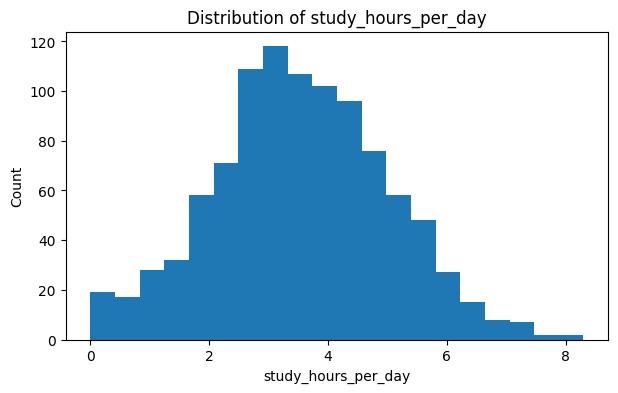

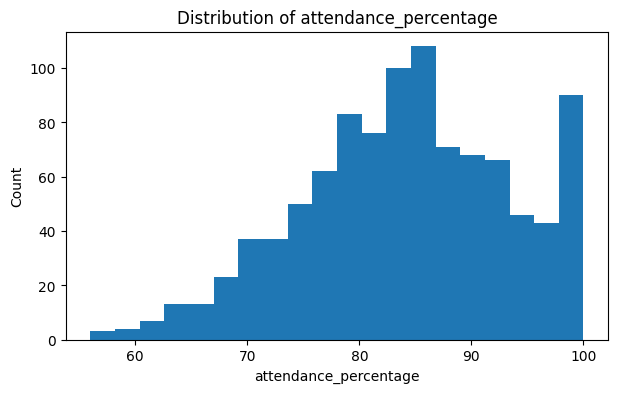

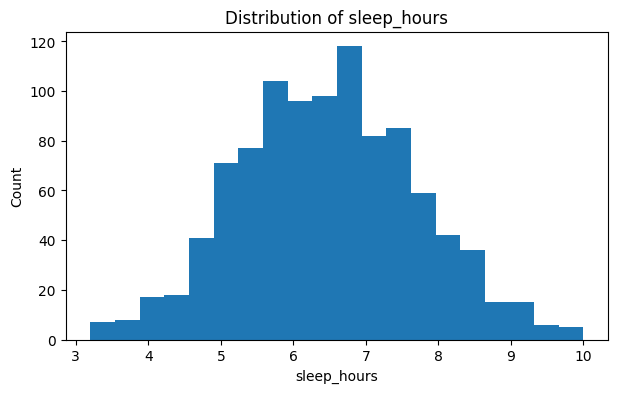

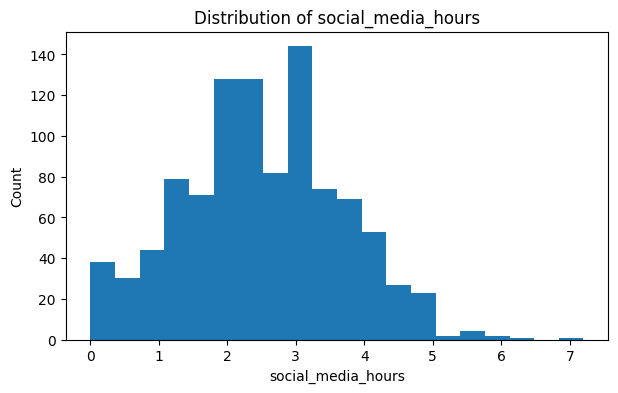

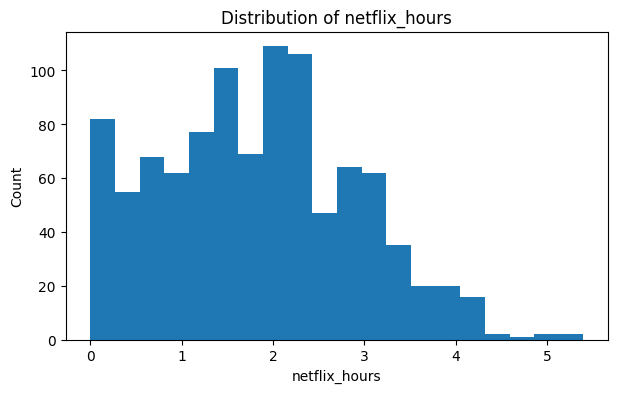

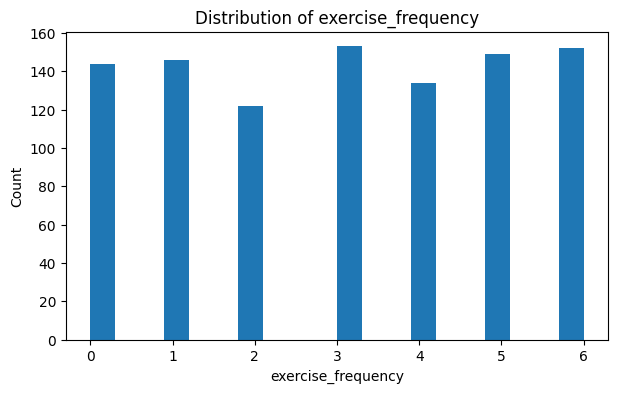

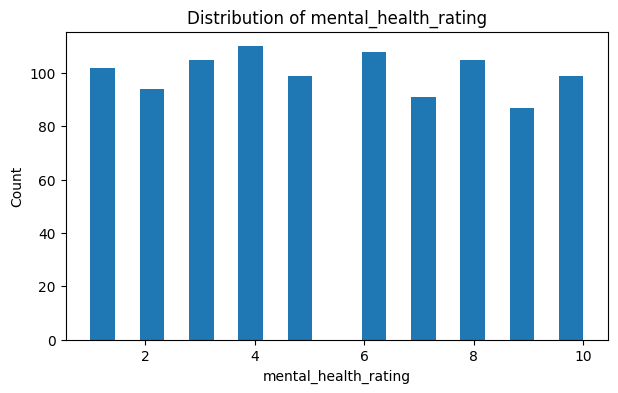

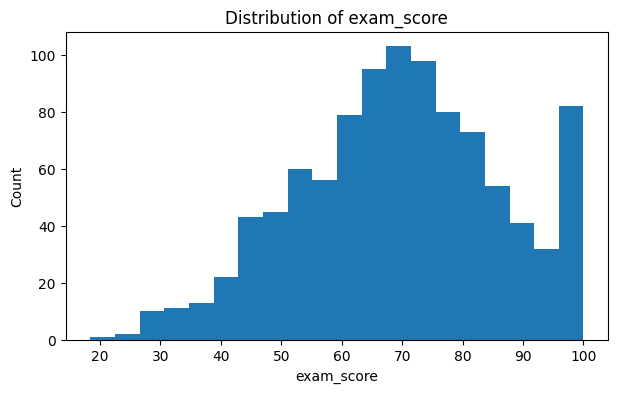

In [12]:
numeric_for_plot = [
    'study_hours_per_day', 'attendance_percentage', 'sleep_hours',
    'social_media_hours', 'netflix_hours', 'exercise_frequency',
    'mental_health_rating', 'exam_score'
]

for col in numeric_for_plot:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col].dropna(), bins=20)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

## 7. Categorical Variable Distributions

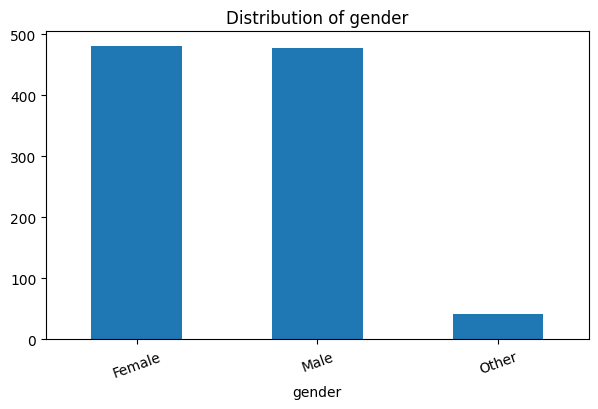

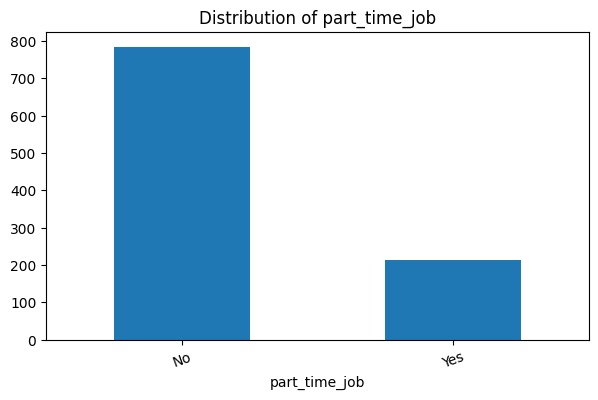

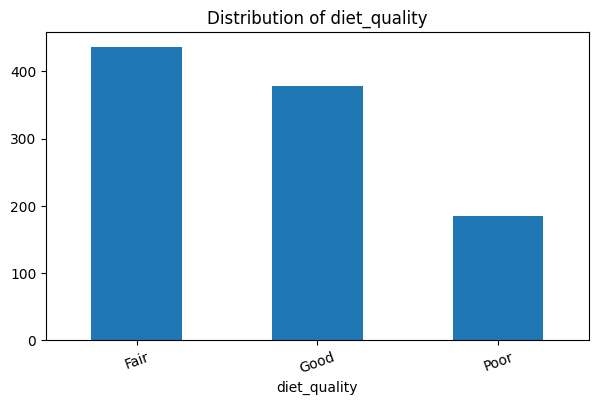

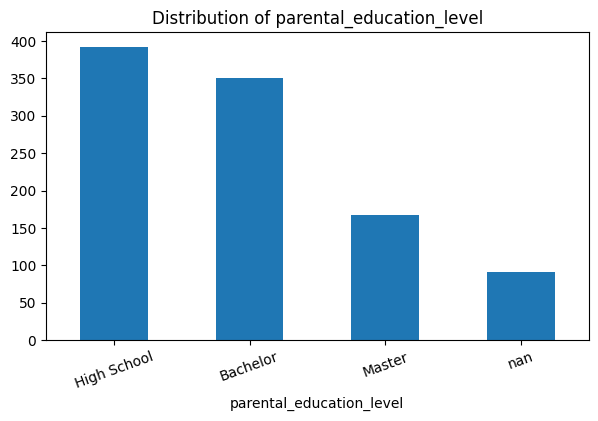

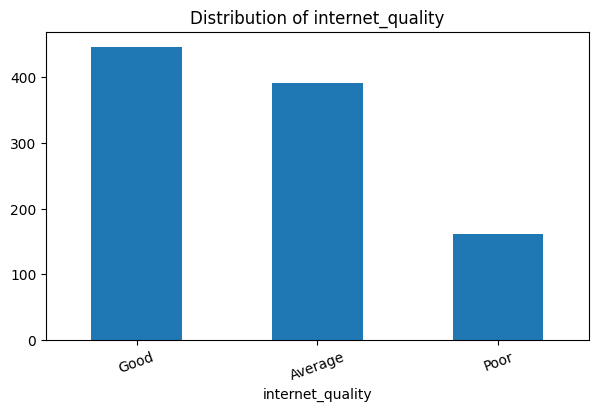

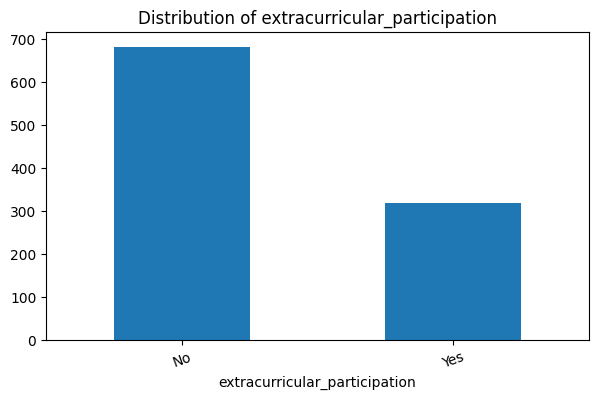

In [13]:
categorical_for_plot = [
    'gender', 'part_time_job', 'diet_quality',
    'parental_education_level', 'internet_quality',
    'extracurricular_participation'
]

for col in categorical_for_plot:
    plt.figure(figsize=(7, 4))
    df[col].value_counts(dropna=False).plot(kind='bar')
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=20)
    plt.show()

## 8. Correlation with `exam_score`

Correlation helps us see which numerical variables have stronger positive or negative relationships with exam score. A value close to +1 means a strong positive relationship, while a value close to -1 means a strong negative relationship.

,Correlation with exam_score
exam_score,1.000000
study_hours_per_day,0.825419
mental_health_rating,0.321523
exercise_frequency,0.160107
sleep_hours,0.121683
attendance_percentage,0.089836
age,-0.008907
social_media_hours,-0.166733
netflix_hours,-0.171779


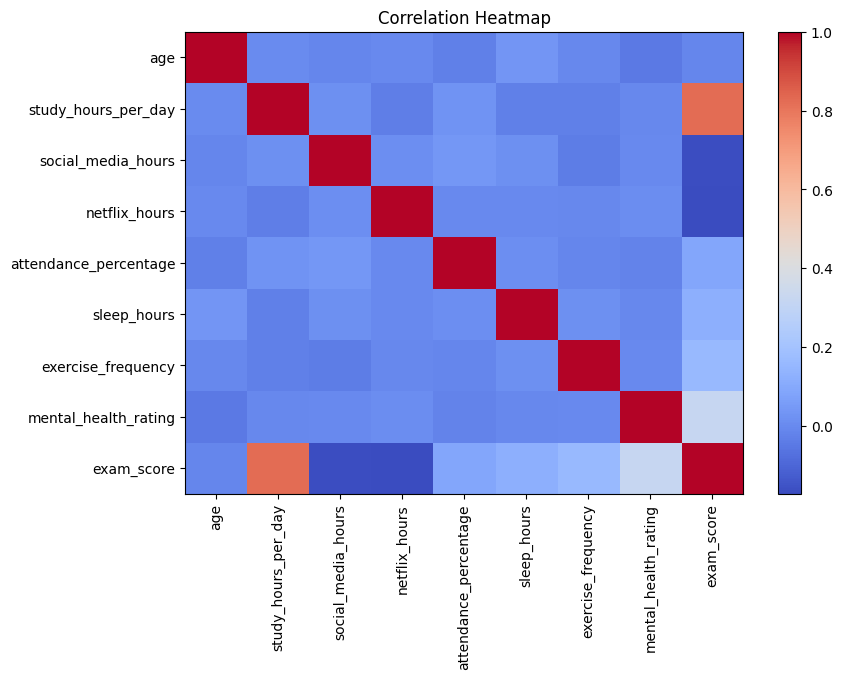

In [14]:
correlation_with_exam = (
    df.select_dtypes(include=np.number)
      .corr()['exam_score']
      .sort_values(ascending=False)
)

display(correlation_with_exam.to_frame("Correlation with exam_score"))

plt.figure(figsize=(9, 6))
plt.imshow(df.select_dtypes(include=np.number).corr(), cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(df.select_dtypes(include=np.number).columns)), df.select_dtypes(include=np.number).columns, rotation=90)
plt.yticks(range(len(df.select_dtypes(include=np.number).columns)), df.select_dtypes(include=np.number).columns)
plt.title("Correlation Heatmap")
plt.show()

## 9. Relationship Between Study Habits and Exam Score

Scatter plots make the relationships easier to understand.

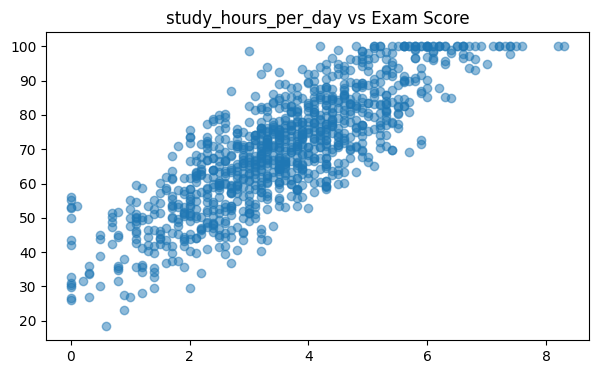

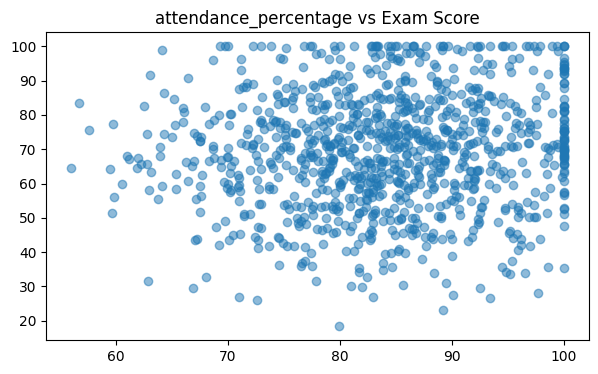

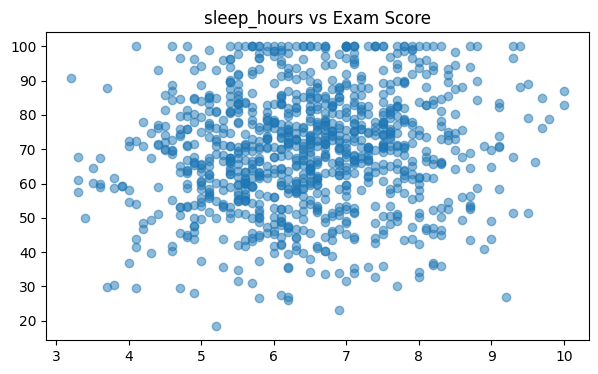

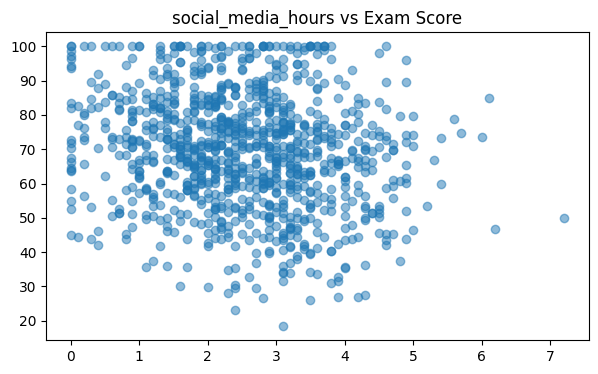

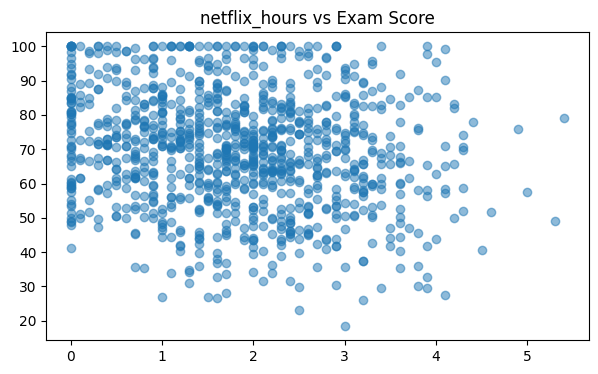

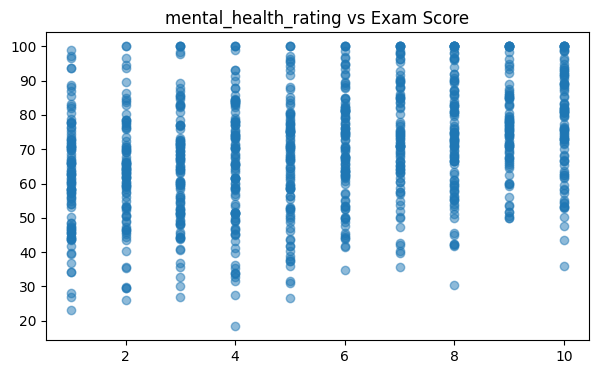

In [15]:
relationship_cols = [
    'study_hours_per_day',
    'attendance_percentage',
    'sleep_hours',
    'social_media_hours',
    'netflix_hours',
    'mental_health_rating'
]

for col in relationship_cols:
    plt.figure(figsize=(7, 4))
    plt.scatter(df[col], df['exam_score'], alpha=0.5)
    plt.title(f"{col} vs Exam Score")
    plt.show()

## 10. Exam Score by Important Categorical Factors

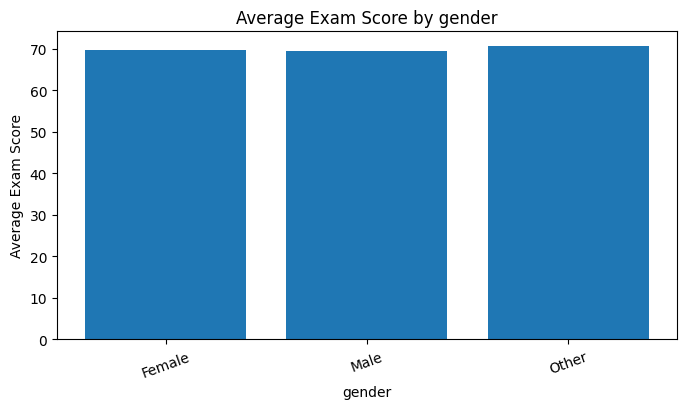

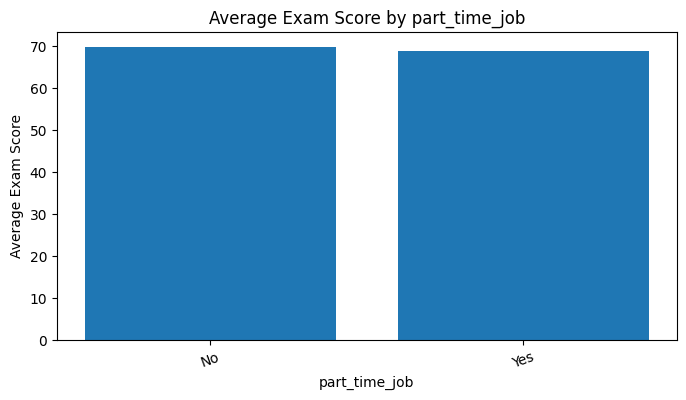

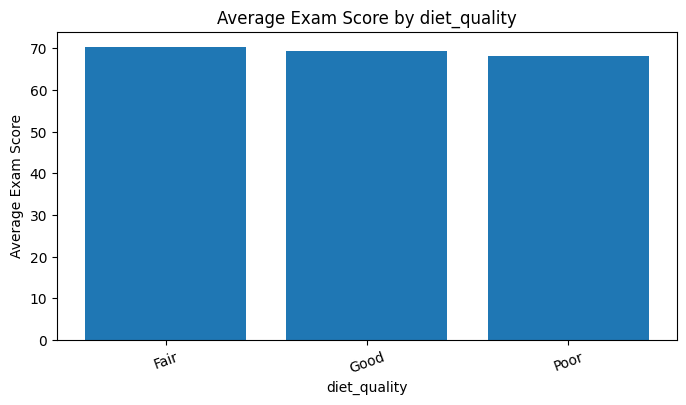

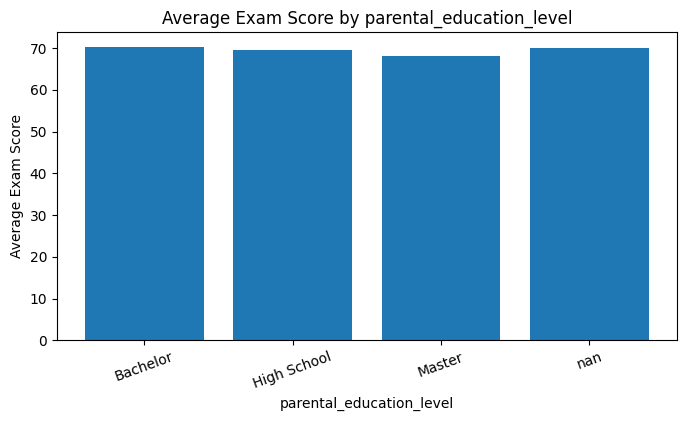

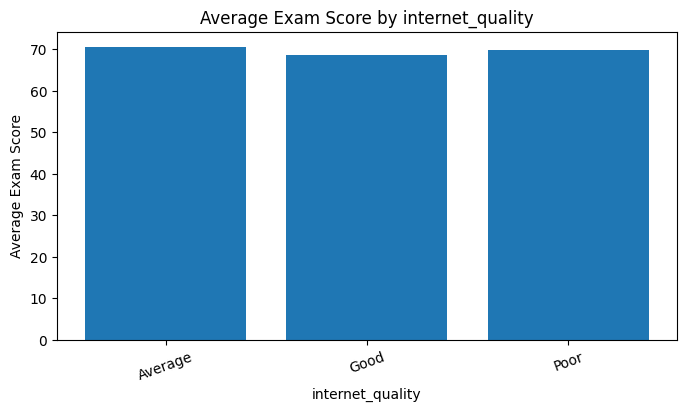

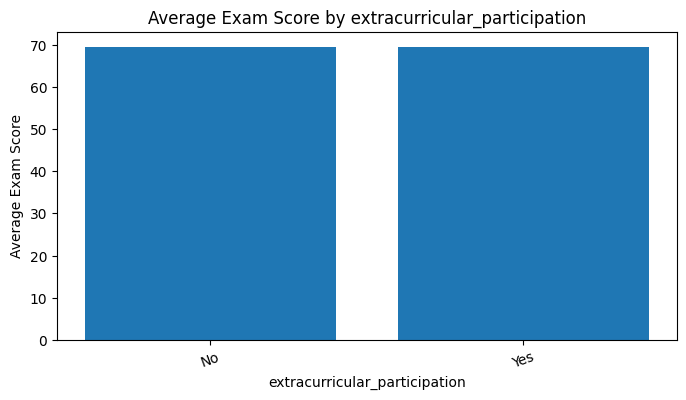

In [16]:
category_relationships = [
    'gender', 'part_time_job', 'diet_quality',
    'parental_education_level', 'internet_quality',
    'extracurricular_participation'
]

for col in category_relationships:
    means = df.groupby(col, dropna=False)['exam_score'].mean()
    labels = [str(x) for x in means.index]
    plt.figure(figsize=(8, 4))
    plt.bar(labels, means.values)
    plt.title(f"Average Exam Score by {col}")
    plt.xlabel(col)
    plt.ylabel("Average Exam Score")
    plt.xticks(rotation=20)
    plt.show()


## 11. Checking Potential Outliers

We use the simple **IQR method**. Values below Q1 − 1.5×IQR or above Q3 + 1.5×IQR are treated as potential outliers.

We identify them but do not automatically delete them because an extreme value can still represent a real student.

In [17]:
outlier_results = []

for col in numeric_for_plot:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_results.append([col, q1, q3, iqr, lower, upper, count])

outlier_table = pd.DataFrame(
    outlier_results,
    columns=['Variable', 'Q1', 'Q3', 'IQR', 'Lower Bound', 'Upper Bound', 'Potential Outliers']
)

display(outlier_table)

,Variable,Q1,Q3,IQR,Lower Bound,Upper Bound,Potential Outliers
0,study_hours_per_day,2.600,4.500,1.900,-0.2500,7.3500,7
1,attendance_percentage,78.000,91.025,13.025,58.4625,110.5625,3
2,sleep_hours,5.600,7.300,1.700,3.0500,9.8500,2
3,social_media_hours,1.700,3.300,1.600,-0.7000,5.7000,5
4,netflix_hours,1.000,2.525,1.525,-1.2875,4.8125,4
5,exercise_frequency,1.000,5.000,4.000,-5.0000,11.0000,0
6,mental_health_rating,3.000,8.000,5.000,-4.5000,15.5000,0
7,exam_score,58.475,81.325,22.850,24.2000,115.6000,2


## 12. EDA Findings

From the EDA, the strongest numerical relationship with `exam_score` is expected to come from study time. Mental health rating also shows a positive relationship, while social media and Netflix hours show negative relationships. Other variables have weaker relationships. These observations will guide, but not restrict, the model features.

In [18]:
print("Top positive/negative numerical relationships with exam_score:")
display(correlation_with_exam.drop('exam_score').sort_values(key=abs, ascending=False).to_frame("Correlation"))

Top positive/negative numerical relationships with exam_score:


,Correlation
study_hours_per_day,0.825419
mental_health_rating,0.321523
netflix_hours,-0.171779
social_media_hours,-0.166733
exercise_frequency,0.160107
sleep_hours,0.121683
attendance_percentage,0.089836
age,-0.008907


## 13. Prepare Data for Machine Learning

We will use the available student information as features, except:
- `exam_score` — this is the regression target.
- `student_id` — this is only an identifier.

For numerical columns, missing values are filled with the median. For categorical columns, missing values are filled with the most frequent category and then converted to numeric values using one-hot encoding.

In [19]:
features = [col for col in df.columns if col not in ['student_id', 'exam_score']]

X = df[features]
y = df['exam_score']

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include='object').columns.tolist()

print("Features used:")
print(features)

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Features used:
['age', 'gender', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'part_time_job', 'attendance_percentage', 'sleep_hours', 'diet_quality', 'exercise_frequency', 'parental_education_level', 'internet_quality', 'mental_health_rating', 'extracurricular_participation']

Numerical features:
['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating']

Categorical features:
['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


In [20]:
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('numeric', numeric_pipeline, numeric_features),
    ('categorical', categorical_pipeline, categorical_features)
])

# Same split will be used for the regression model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 800
Testing rows: 200


## 14. Train Linear Regression Model

Linear Regression is suitable here because `exam_score` is a continuous numerical value.

In [21]:
regression_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

regression_model.fit(X_train, y_train)

train_predictions = regression_model.predict(X_train)
test_predictions = regression_model.predict(X_test)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


## 15. Regression Evaluation

We use three simple regression metrics:

- **MAE:** Average absolute prediction error. Lower is better.
- **RMSE:** Gives more weight to larger errors. Lower is better.
- **R²:** Proportion of variation explained by the model. Higher is better.

In [22]:
train_mae = mean_absolute_error(y_train, train_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)

train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

regression_results = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R² Score'],
    'Training': [train_mae, train_rmse, train_r2],
    'Testing': [test_mae, test_rmse, test_r2]
})

display(regression_results.round(4))

,Metric,Training,Testing
0,MAE,4.2142,4.1923
1,RMSE,5.3447,5.1510
2,R² Score,0.9021,0.8965


## 16. Actual vs Predicted Exam Scores

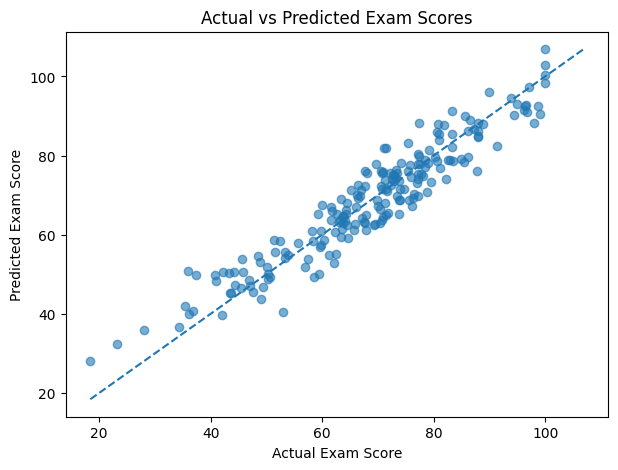

In [23]:
plt.figure(figsize=(7, 5))
plt.scatter(y_test, test_predictions, alpha=0.6)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")

# Reference line
min_score = min(y_test.min(), test_predictions.min())
max_score = max(y_test.max(), test_predictions.max())
plt.plot([min_score, max_score], [min_score, max_score], linestyle='--')

plt.show()

## 17. Create Pass/Fail Target

For classification, we convert `exam_score` into two classes:

- **Pass = 1:** exam score >= 50
- **Fail = 0:** exam score < 50

In [24]:
df['pass_fail'] = (df['exam_score'] >= 50).astype(int)

print("Pass/Fail counts:")
display(df['pass_fail'].value_counts().rename(index={0: 'Fail', 1: 'Pass'}).to_frame('Students'))

print("\nPass percentage:", round(df['pass_fail'].mean() * 100, 2), "%")

Pass/Fail counts:


,Students
pass_fail,
Pass,869
Fail,131



Pass percentage: 86.9 %


## 18. Prepare Data for Classification

We use the same student features as before. The new target is `pass_fail`.

In [25]:
X_class = df[features]
y_class = df['pass_fail']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_class,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("Classification training rows:", X_train_c.shape[0])
print("Classification testing rows:", X_test_c.shape[0])

Classification training rows: 800
Classification testing rows: 200


## 19. Train Logistic Regression Classification Model

Logistic Regression is a simple and suitable model for a binary Pass/Fail problem.

In [26]:
classification_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

classification_model.fit(X_train_c, y_train_c)

train_class_predictions = classification_model.predict(X_train_c)
test_class_predictions = classification_model.predict(X_test_c)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


## 20. Classification Evaluation

We evaluate the model using:

- **Accuracy:** Overall percentage of correct predictions.
- **Precision:** Of the students predicted as Pass, how many actually passed?
- **Recall:** Of the students who actually passed, how many were correctly identified?
- **F1-score:** Balance between precision and recall.

In [27]:
train_accuracy = accuracy_score(y_train_c, train_class_predictions)
test_accuracy = accuracy_score(y_test_c, test_class_predictions)

train_precision = precision_score(y_train_c, train_class_predictions)
test_precision = precision_score(y_test_c, test_class_predictions)

train_recall = recall_score(y_train_c, train_class_predictions)
test_recall = recall_score(y_test_c, test_class_predictions)

train_f1 = f1_score(y_train_c, train_class_predictions)
test_f1 = f1_score(y_test_c, test_class_predictions)

classification_results = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Training': [train_accuracy, train_precision, train_recall, train_f1],
    'Testing': [test_accuracy, test_precision, test_recall, test_f1]
})

display(classification_results.round(4))

,Metric,Training,Testing
0,Accuracy,0.9562,0.960
1,Precision,0.9728,0.977
2,Recall,0.9770,0.977
3,F1-score,0.9749,0.977


## 21. Confusion Matrix

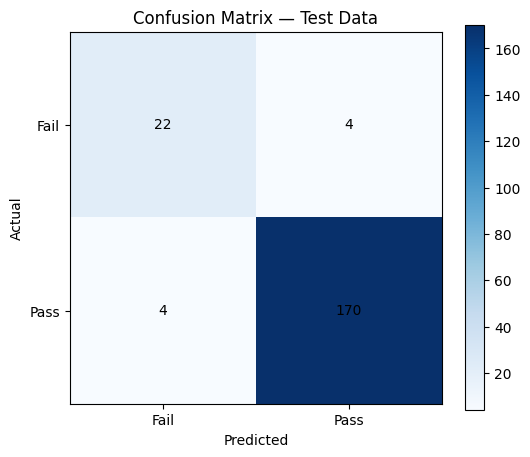

Confusion Matrix:
[[ 22   4]
 [  4 170]]


In [28]:
cm = confusion_matrix(y_test_c, test_class_predictions)

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks([0, 1], ['Fail', 'Pass'])
plt.yticks([0, 1], ['Fail', 'Pass'])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Data")
plt.show()

print("Confusion Matrix:")
print(cm)

## 22. Training vs Testing Performance

Comparing training and testing scores helps identify overfitting or underfitting.

- If training performance is much better than testing performance, the model may be **overfitting**.
- If both are poor, the model may be **underfitting**.
- If both are close and reasonably strong, the model is likely generalizing well.

In [29]:
print("REGRESSION")
print(f"Training R²: {train_r2:.4f}")
print(f"Testing R² : {test_r2:.4f}")
print(f"R² difference: {abs(train_r2 - test_r2):.4f}")

print("\nCLASSIFICATION")
print(f"Training Accuracy: {train_accuracy:.4f}")
print(f"Testing Accuracy : {test_accuracy:.4f}")
print(f"Accuracy difference: {abs(train_accuracy - test_accuracy):.4f}")

if abs(train_r2 - test_r2) < 0.10 and abs(train_accuracy - test_accuracy) < 0.10:
    print("\nConclusion: Training and testing performance are close, so there is no strong sign of overfitting.")
else:
    print("\nConclusion: There is a noticeable train-test difference; investigate possible overfitting.")

REGRESSION
Training R²: 0.9021
Testing R² : 0.8965
R² difference: 0.0056

CLASSIFICATION
Training Accuracy: 0.9563
Testing Accuracy : 0.9600
Accuracy difference: 0.0037

Conclusion: Training and testing performance are close, so there is no strong sign of overfitting.


## 23. Important Findings from the Model

The regression model gives a direct estimate of exam score, while the classification model predicts whether a student is likely to pass. The test metrics should be preferred when discussing how the models may perform on unseen students.

In [30]:
print(f"Regression test MAE: {test_mae:.2f} marks")
print(f"Regression test RMSE: {test_rmse:.2f} marks")
print(f"Regression test R²: {test_r2:.3f}")

print(f"Classification test accuracy: {test_accuracy:.3f}")
print(f"Classification test precision: {test_precision:.3f}")
print(f"Classification test recall: {test_recall:.3f}")
print(f"Classification test F1-score: {test_f1:.3f}")

Regression test MAE: 4.19 marks
Regression test RMSE: 5.15 marks
Regression test R²: 0.897
Classification test accuracy: 0.960
Classification test precision: 0.977
Classification test recall: 0.977
Classification test F1-score: 0.977


## 24. Final 5 Insights About Student Performance

1. **Study hours are the strongest numerical factor:** `study_hours_per_day` has a strong positive correlation with exam score (about **0.83**), making it the clearest relationship in the dataset.

2. **Mental health has a positive relationship:** `mental_health_rating` has a moderate positive correlation with exam score (about **0.32**), suggesting that better reported mental well-being is associated with higher scores in this dataset.

3. **Entertainment/social-media time shows a negative relationship:** `social_media_hours` and `netflix_hours` have negative correlations with exam score (about **-0.17** and **-0.17**), although correlation does not prove causation.

4. **The regression model performs well on unseen data:** The test R² is about **0.90**, with an MAE of about **4.19 marks**, meaning the model explains a large portion of score variation with an average absolute error of roughly 4 marks.

5. **Pass/Fail classification generalizes well:** The test accuracy is about **96%**, with precision, recall and F1-score all about **0.98**. Training and testing results are very close, so there is no strong evidence of overfitting.

In [31]:
# Automatically display the main numerical EDA findings used in the conclusion
print("Key correlations:")
for col in [
    'study_hours_per_day', 'mental_health_rating',
    'exercise_frequency', 'sleep_hours',
    'attendance_percentage', 'social_media_hours', 'netflix_hours'
]:
    print(f"{col}: {df[col].corr(df['exam_score']):.3f}")

print("\nModel summary:")
print(f"Regression Test R² = {test_r2:.3f}")
print(f"Regression Test MAE = {test_mae:.3f}")
print(f"Classification Test Accuracy = {test_accuracy:.3f}")
print(f"Classification Test F1 = {test_f1:.3f}")

Key correlations:
study_hours_per_day: 0.825
mental_health_rating: 0.322
exercise_frequency: 0.160
sleep_hours: 0.122
attendance_percentage: 0.090
social_media_hours: -0.167
netflix_hours: -0.172

Model summary:
Regression Test R² = 0.897
Regression Test MAE = 4.192
Classification Test Accuracy = 0.960
Classification Test F1 = 0.977
